## 1. 处理 JSON

In [2]:
import json, pandas as pd
import numpy as np

with open('labling.json', 'r') as f:
    tasks = json.load(f)

rows = []
for t in tasks:
    task_id = t.get("id")
    file_upload = t.get("file_upload")
    ecg_path = (t.get("data") or {}).get("ecg")

    for ann in t.get("annotations", []):
        ann_id = ann.get("id")
        completed_by = ann.get("completed_by")
        created_at = ann.get("created_at")

        for r in ann.get("result", []):
            if r.get("type") != "timeserieslabels":
                continue

            v = r.get("value", {})
            label = (v.get("timeserieslabels") or [None])[0]

            rows.append({
                "task_id": task_id,
                "file_upload": file_upload,
                "ecg_path": ecg_path,
                "ann_id": ann_id,
                "completed_by": completed_by,
                "created_at": created_at,
                "seg_id": r.get("id"),
                "from_name": r.get("from_name"),
                "to_name": r.get("to_name"),
                "start": v.get("start"),
                "end": v.get("end"),
                "instant": v.get("instant"),
                "label": label,
                "origin": r.get("origin"),
            })

df = pd.DataFrame(rows).sort_values(["task_id", "start"]).reset_index(drop=True)

## 2. 从 JSON 里获取 ECG 文件名

In [2]:
ls = df[df['ann_id'] == 3]
labels = ls.loc[:, ['start', 'end', 'label']]

s = list(set(ls['file_upload']))[0]
ecg_filename = s[s.find('ecg'):]

ecg = pd.read_csv(ecg_filename)

## 3. 通过时间戳寻找标注的index

In [3]:
t = ecg['time'].values
L = labels.copy()
start_idx = np.searchsorted(t, L["start"].values, side="left")
end_idx = np.searchsorted(t, L["end"].values, side="right")
L["start_idx"] = start_idx
L["end_idx"] = end_idx

segs = L.loc[:, 'label':]
uncertain_segs = segs[segs['label'] == 'Uncertain']
bad_segs = segs[segs['label'] == 'Bad']


mask = np.ones(len(ecg), dtype=bool)

for row in bad_segs.itertuples():
    mask[row.start_idx:row.end_idx] = False

ecg_clean = ecg[mask].reset_index(drop=True)

In [8]:
def show_ecg_info(df):
    n_samples = len(df)
    duration = df["time"].iloc[-1] - df["time"].iloc[0]
    dt = np.diff(df["time"])
    fs = 1 / np.median(dt)

    print(f"Samples: {n_samples}")
    print(f"Duration: {duration/3600:.2f} hours")
    print(f"Estimated sampling rate: {fs:.2f} Hz")
    return

In [4]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(ecg_clean['ecg'], height=350, distance=20)

r_series = ecg_clean.loc[peaks, 'time']
rr_s = np.diff(r_series)
rr_s = rr_s[rr_s < 2]
hr = (60 / rr_s).astype(int)

rr_ms = rr_s * 1000 # ms
rr_ms = rr_ms[rr_ms < 2000]
sdnn = np.std(rr_ms, ddof=1)  # ms
rmssd = np.sqrt(np.mean(np.diff(rr_ms) ** 2))  # ms


In [1]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(6,6))
plt.scatter(
    rr_ms[1:], rr_ms[:-1], 
    s=10, alpha=0.2, edgecolors='k',
    grid=True
    )

plt.xlabel('RR Interval (ms)')
plt.ylabel('RR Interval (ms)')

NameError: name 'rr_ms' is not defined

<Figure size 600x600 with 0 Axes>

10179 707.6811548745144 57.09301808030909
9399


(array([1.230e+02, 8.740e+02, 3.049e+03, 3.386e+03, 2.053e+03, 4.830e+02,
        1.660e+02, 3.300e+01, 9.000e+00, 3.000e+00]),
 array([ 541.58306122,  591.84896946,  642.1148777 ,  692.38078594,
         742.64669418,  792.91260242,  843.17851067,  893.44441891,
         943.71032715,  993.97623539, 1044.24214363]),
 <BarContainer object of 10 artists>)

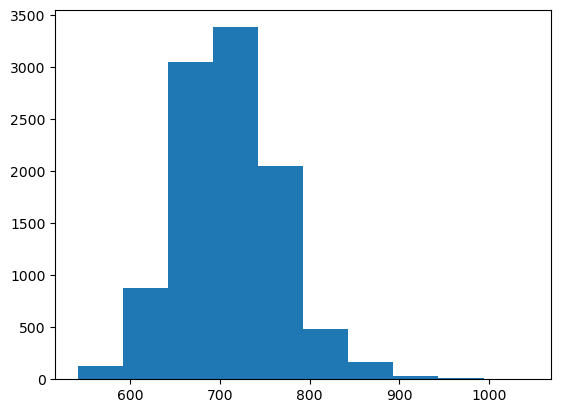

In [6]:
print(len(rr_ms), np.mean(rr_ms), np.std(rr_ms))
print(len(set(rr_ms)))
plt.hist(rr_ms, bins=10)

In [7]:
rr_diff = pd.DataFrame({'rr1':rr_ms[1:], 'rr2':rr_ms[:-1]})
rr_diff.to_csv('rr_diff_test.csv')

In [167]:
# 看 RR * fs / 1000 是否接近整数
test = rr_ms * 50 / 1000
print(np.max(np.abs(test - np.round(test))))

0.475644588470459


In [9]:
show_ecg_info(ecg_clean)

Samples: 359249
Duration: 2.02 hours
Estimated sampling rate: 49.90 Hz
